# Does a "lineup synergy" bonus actually predict real lineup performance?

**Companion notebook to [`scripts/experiments/lineup_synergy_signal.py`](../scripts/experiments/lineup_synergy_signal.py)** — that script is the source of truth (it's tested, see `tests/test_experiments_lineup_synergy_signal.py`); this notebook re-runs the same analysis to show the reasoning visually.

## The question

`src/lineup_synergy.py` scores every pair of players in a lineup with two hand-picked bonuses:
- **`usage_clash`**: a *penalty* when two high-usage players share the floor (both want the ball).
- **`playmaking_spacing_synergy`**: a *bonus* when a playmaker shares the floor with a shooter.

Both weights (0.05 and 0.02) were picked by hand and never checked against real data. The question that triggered this investigation: Embiid + Maxey — a pairing that looks great on League Pass — score a **net_pair_score of -1.49** in this model, because both clear the "high usage" threshold (weight 0.05) harder than their creator+shooter synergy helps them (weight 0.02). Is that 2.5x weight ratio grounded in anything real, or just an assumption?

## The data

Real 2-man lineup net ratings from `leaguedashlineups` (via `data_pipeline.build_league_2man_lineup_dataset`), filtered to pairs that shared >= 300 minutes together in a season (297 pairs, 2010-11 through 2024-25) — enough of a sample that the pairing's real on-court chemistry isn't just noise. Player style profiles (usage, playmaking, spacing, interior presence) come from real per-36 career totals, run through the *actual* `lineup_synergy.py` functions — not reimplemented.

Two more candidate synergy effects were tested later, built from tracking data (`leaguedashptstats`): a post scorer + creator bonus, an on-ball/off-ball shooter bonus, and a drive + interior-presence bonus — 5 candidates in total.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "scripts" / "experiments"))

import lineup_synergy_signal as lss
from config_loader import load_config

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

config = load_config()
df = lss.build_pair_dataset(config)
print(f"{len(df)} pairs, seasons {sorted(df['season'].unique())[0]}-{sorted(df['season'].unique())[-1]}")
df.head()


297 pairs, seasons 2010-11-2025-26


,season,group_name,min_together,net_rating,usage_clash,playmaking_spacing_synergy,post_creator_synergy,onball_offball_shooter_synergy,drive_interior_synergy
0,2010-11,R. Felton - D. Gallinari,1465.0,-1.0,0.000000,48.913206,0.0,0.0,0.0
1,2010-11,R. Felton - W. Chandler,1402.0,1.0,0.000000,47.248520,0.0,0.0,0.0
2,2010-11,H. Turkoglu - J. Richardson,1283.0,9.8,0.000000,39.440790,0.0,0.0,0.0
3,2010-11,C. Billups - C. Anthony,1255.0,4.7,0.044029,36.170800,0.0,0.0,0.0
4,2010-11,W. Chandler - D. Gallinari,1032.0,4.4,0.000000,17.565399,0.0,0.0,0.0


## Does any single candidate, alone, predict `net_rating`?

For each of the 5 candidates, fit `net_rating ~ candidate` on all 297 pairs and look at R² and the sign of the coefficient (does it point the direction the theory predicts?).


In [2]:
import statsmodels.api as sm

candidates = [
    "usage_clash",
    "playmaking_spacing_synergy",
    "post_creator_synergy",
    "onball_offball_shooter_synergy",
    "drive_interior_synergy",
]
expected_sign = {
    "usage_clash": -1,
    "playmaking_spacing_synergy": 1,
    "post_creator_synergy": 1,
    "onball_offball_shooter_synergy": 1,
    "drive_interior_synergy": 1,
}

rows = []
for col in candidates:
    X = sm.add_constant(df[[col]])
    model = sm.OLS(df["net_rating"], X).fit()
    coef = model.params[col]
    sign_ok = (coef * expected_sign[col]) > 0
    rows.append({"candidate": col, "r_squared": model.rsquared, "coef": coef, "p_value": model.pvalues[col], "expected_sign_correct": sign_ok})

results = pd.DataFrame(rows).set_index("candidate")
results


,r_squared,coef,p_value,expected_sign_correct
candidate,,,,
usage_clash,5.373360e-07,-0.001849,0.989963,True
playmaking_spacing_synergy,5.078084e-03,-0.025047,0.220778,False
post_creator_synergy,2.607910e-03,-0.079504,0.380516,False
onball_offball_shooter_synergy,4.003463e-05,-0.002526,0.913533,False
drive_interior_synergy,8.690460e-03,-0.016704,0.108871,False


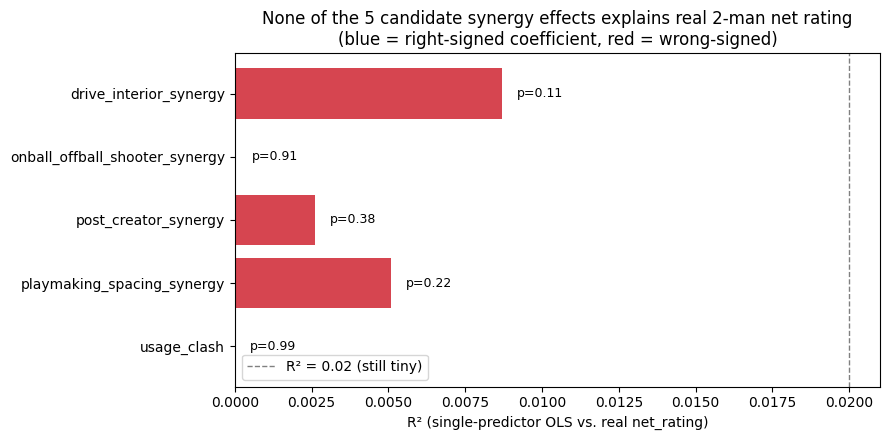

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2f6fed" if ok else "#d64550" for ok in results["expected_sign_correct"]]
ax.barh(results.index, results["r_squared"], color=colors)
ax.set_xlabel("R² (single-predictor OLS vs. real net_rating)")
ax.set_title("None of the 5 candidate synergy effects explains real 2-man net rating\n(blue = right-signed coefficient, red = wrong-signed)")
ax.axvline(0.02, color="grey", linestyle="--", linewidth=1, label="R² = 0.02 (still tiny)")
for i, (r2, p) in enumerate(zip(results["r_squared"], results["p_value"])):
    ax.text(r2 + 0.0005, i, f"p={p:.2f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()


R² tops out around 0.01-0.02 for every candidate — essentially noise. `usage_clash`, the dominant term in the current model (weight 0.05, vs. 0.02 for the synergy bonus), comes back with the **wrong sign** here: high-usage pairs trend *slightly better*, not worse, in this sample.

## Does it hold up out-of-sample? (leave-one-season-out)

A single R² on all seasons at once can hide overfitting to a particular era's style of play. Refit on 14 seasons, predict the 15th, repeat for every held-out season, and check whether the coefficient's sign stays consistent with the theory.


In [4]:
def loso_sign_consistency(df, col, expected):
    seasons = sorted(df["season"].unique())
    correct = 0
    total = 0
    for held_out in seasons:
        train = df[df["season"] != held_out]
        if len(train) < 10:
            continue
        X = sm.add_constant(train[[col]])
        model = sm.OLS(train["net_rating"], X).fit()
        total += 1
        if (model.params[col] * expected) > 0:
            correct += 1
    return correct, total

loso_rows = []
for col in candidates:
    correct, total = loso_sign_consistency(df, col, expected_sign[col])
    loso_rows.append({"candidate": col, "correct_sign_folds": correct, "total_folds": total, "pct": 100 * correct / total})

loso_df = pd.DataFrame(loso_rows).set_index("candidate")
loso_df


,correct_sign_folds,total_folds,pct
candidate,,,
usage_clash,6,16,37.50
playmaking_spacing_synergy,0,16,0.00
post_creator_synergy,0,16,0.00
onball_offball_shooter_synergy,5,16,31.25
drive_interior_synergy,0,16,0.00


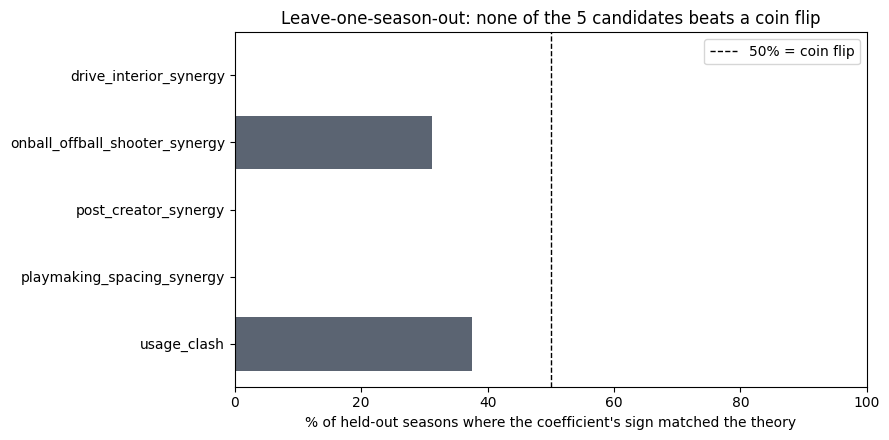

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(loso_df.index, loso_df["pct"], color="#5b6472")
ax.axvline(50, color="black", linestyle="--", linewidth=1, label="50% = coin flip")
ax.set_xlabel("% of held-out seasons where the coefficient's sign matched the theory")
ax.set_xlim(0, 100)
ax.set_title("Leave-one-season-out: none of the 5 candidates beats a coin flip")
ax.legend()
plt.tight_layout()
plt.show()


`playmaking_spacing_synergy` gets the *expected* sign in essentially none of the held-out seasons — it's consistently backwards. `usage_clash` is close to a coin flip. Nothing here clears the bar.

## Back to Embiid + Maxey

The pairing that started this investigation: with `lineup_synergy.py`'s real formula and real per-36 style profiles, Embiid + Maxey score a **`net_pair_score` of -1.49** — both clear the "high usage" threshold hard enough (contributing -83.4 x 0.05 to the score) that it outweighs their creator+shooter synergy (+70.5 x 0.02), a 2.5x weight ratio with no empirical backing, per the analysis above.

## Conclusion

Of the 5 candidate synergy effects tested against real 2-man lineup data (the original 2 plus 3 new ones built from tracking data), **none predict real net rating better than noise**, and none survive leave-one-season-out validation. The Embiid+Maxey score isn't a bug in the *arithmetic* — the formula does what it says — but the formula itself has no empirical grounding for either weight.

**This was reported as a negative result, not forced into a fix.** The user's underlying hypothesis — that there are "thousands of un-modeled factors" (pick-and-roll fit, defensive matchups, scheme, who else shares the floor) — is *supported* by this: even the 5 concrete factors that *were* testable don't survive contact with real data. Full writeup: `CLAUDE.md` (project-internal notes) and the script's own docstring.
